In [22]:
import polars as pl
import numpy as np
import datetime as dt
import sf_quant.data as sfd
import sf_quant.research as sfr
import polars_ols
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd

In [28]:
start = dt.date(1987, 1, 1)
end = dt.date(2023, 12, 31)
signal_name = "IS2"
price_filter = 5
IC = 0.05
# print(sfd.get_assets_columns())

data = sfd.load_assets(
    start=start,
    end=end,
    columns=[
        "date",
        "barrid",
        "price",
        "return",
        "specific_risk",
        "predicted_beta",
        "market_cap",
        "daily_volume", 
        "specific_return"
    ],
    in_universe=True,
).with_columns(pl.col("return",  "specific_return", "specific_risk").truediv(100))

# T=5
# days=T*21

df = data.sort(["barrid", "date"])


# calculates turnover 
df = df.with_columns(
    (pl.col("daily_volume") / pl.col("market_cap")).alias("turnover")
)

# Get last trading day of each month per stock
df = df.with_columns([
    pl.col("date").cast(pl.Datetime).alias("date_dt"),])

# Create month indicator
df = df.with_columns(
    (pl.col("date_dt").dt.year() * 100 + pl.col("date_dt").dt.month()).alias("yyyymm")
)

# does dummy variable for marketcap
df = df.with_columns(
    pl.col("market_cap")
      .rank(method="average")
      .over("date")
      .alias("rank")
).with_columns(
    (pl.col("rank") /
     pl.col("rank").max().over("date") * 3)
    .ceil()
    .alias("mktcap_bin"))

df = df.with_columns(
    pl.col("mktcap_bin").cast(pl.Utf8)
).to_dummies("mktcap_bin")


df = df.with_columns(pl.col('mktcap_bin_3.0').alias('curmktb3'))
df = df.with_columns(pl.col('mktcap_bin_2.0').alias('curmktb2'))
df = df.with_columns(pl.col('mktcap_bin_1.0').alias('curmktb1'))
df = df.drop(['rank', 'mktcap_bin_3.0', 'mktcap_bin_2.0', 'mktcap_bin_1.0'])
# df = df.with_columns(
#     pl.col("market_cap")
#       .qcut(3)
#       .over("date")
#       .cast(pl.Utf8)
#       .alias("mktcap_bin"))

# df = df.to_dummies(columns=["mktcap_bin"])

# df = df.drop("mktcap_bin_2")


# print(df)



T = 60
days= 21*T
df = df.sort(["barrid","yyyymm"])

# # current period
df = df.with_columns([
    # MOMENTUM
    pl.col("specific_return").log1p().shift(42).rolling_sum(window_size=12*21).over("barrid").alias("curmom"),
    
    # volitility
    pl.col("specific_return").shift(0).rolling_std(window_size=days).over("barrid").alias("curvol"),
    
    # Skewness
    pl.col("specific_return").shift(0).rolling_skew(window_size=days).over("barrid").alias("curskew"),
    
    # Turnover
    # pl.col("turnover").shift(1).rolling_mean(window_size=T).over("barrid").alias("curturn")])
    pl.col("turnover").shift(21).rolling_sum(window_size=days).over("barrid").alias("curturn")])



    # mktbin
# # previous
df = df.with_columns([
#     # MOMENTUM
    pl.col("specific_return").log1p().shift(days+42).rolling_sum(window_size=12*21).over("barrid").alias("prevmom"),
    
    # volitility
    pl.col("specific_return").shift(days+21).rolling_std(window_size=days).over("barrid").alias("prevvol"),
    
    # Skewness
    pl.col("specific_return").shift(days).rolling_skew(window_size=days).over("barrid").alias("prevskew"),
    
    # Turnover
    # pl.col("turnover").shift(1+T).rolling_mean(window_size=T).over("barrid").alias("prevturn"),
    pl.col("turnover").shift(days+21).rolling_sum(window_size=days).over("barrid").alias("prevturn"),

    
    # mktcap
    pl.col("curmktb1").shift(21).over("barrid").alias("prevmktb1"),
    pl.col("curmktb2").shift(21).over("barrid").alias("prevmktb2"),
    pl.col("curmktb3").shift(21).over("barrid").alias("prevmktb3")])

# # last trading day per month
monthly_df = df.group_by(["barrid", "yyyymm"]).agg([
    pl.col("specific_return").last().alias("specific_return"),
    pl.col("turnover").mean().alias("turnover"),
    pl.col("market_cap").last().alias("market_cap"),
    pl.col("price").last().alias("price"),
    pl.col("predicted_beta").last().alias("predicted_beta"),
    pl.col("specific_risk").last().alias("specific_risk"),
    pl.col("date").last().alias("date"),
    pl.col("return").last().alias("return"),
    
    pl.col("prevmktb2").last().alias("prevmktb2"),
    pl.col("prevmktb1").last().alias("prevmktb1"),
    pl.col("curmktb2").last().alias("curmktb2"),
    pl.col("curmktb1").last().alias("curmktb1"),
    pl.col("curmktb3").last().alias("curmktb3"),
    pl.col("prevmktb3").last().alias("prevmktb3"), 
    
    pl.col("prevmom").last().alias("prevmom"),
    pl.col("prevturn").last().alias("prevturn"),   
    pl.col("prevskew").last().alias("prevskew"),
    pl.col("prevvol").last().alias("prevvol"),   
    
    pl.col("curmom").last().alias("curmom"),
    pl.col("curturn").last().alias("curturn"),   
    pl.col("curskew").last().alias("curskew"),
    pl.col("curvol").last().alias("curvol"), 
    
])

monthly_df = monthly_df.with_columns(pl.col('market_cap').shift(1).alias('mktcap_lag'))



# # Drop rows with missing values
monthly_df = monthly_df.drop_nulls(["curmom", "curvol", "curskew", "curturn", "market_cap", "prevmom", "prevvol", "prevskew", "prevturn",'prevmktb1', 'prevmktb2'])

# # ols per mounth
def cross_sectional_ols(df_month):
    X = df_month[["prevmom", "prevvol", "prevskew", "prevturn", 'prevmktb1','prevmktb2']]
    y = df_month["curskew"]  
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    coef_dict = model.params.to_dict()
    return model

# # Shift skew by -1 month to get next month skew
# monthly_df = monthly_df.sort(["barrid","yyyymm"])
# monthly_df = monthly_df.with_columns(
#     pl.col("curskew").shift(-1).over("barrid").alias("skew_next")  
# )

# monthly_df = monthly_df.drop_nulls(["skew_next"])

# # run cross-sectional regression
coeffs_list = []
monthly= []
monthly_df = monthly_df.sort(["barrid","yyyymm"])


for month, df_month in monthly_df.group_by("yyyymm"):
    df_month_pd = df_month.to_pandas()
    model = cross_sectional_ols(df_month_pd)
    coeffs_list.append(model)
    params = model.params.to_dict()

    monthly.append([month[0], params['const'],params['prevmom'], params['prevvol'], params['prevskew'], params['prevturn'], params['prevmktb1'], params['prevmktb2']])

# # monthly1 has all of the monthly results of the regression, merges it onto monthly_df
monthly1 = pd.DataFrame(monthly, columns=['yyyymm', 'const', 'Bprevmom', 'Bprevvol', 'Bprevskew', 'Bprevturn', 'Bprevmktb1', 'Bprevmktb2'])
monthly1 = pl.from_pandas(monthly1)
monthly_df= monthly_df.join(monthly1, on='yyyymm', how='left')


avgcoeffs = monthly1[['const', 'Bprevmom', 'Bprevvol', 'Bprevskew', 'Bprevturn', 'Bprevmktb1', 'Bprevmktb2']].mean()
print(avgcoeffs)

# # Compute expected skewness using past characteristics
monthly_df = monthly_df.with_columns(
    (
        pl.col("const")
        + pl.col("Bprevskew") * pl.col("curskew")
        + pl.col("Bprevvol") * pl.col("curvol")
        + pl.col("Bprevmom") * pl.col("curmom")
        + pl.col("Bprevturn") * pl.col("curturn")
        + pl.col("Bprevmktb1") * pl.col("curmktb1")
        + pl.col("Bprevmktb2") * pl.col('curmktb2')
    ).alias(signal_name)
)

# monthly_df = monthly_df.with_columns(pl.col(signal_name).shift(-T).alias(signal_name))


shape: (1, 7)
┌───────────┬───────────┬───────────┬───────────┬───────────┬────────────┬────────────┐
│ const     ┆ Bprevmom  ┆ Bprevvol  ┆ Bprevskew ┆ Bprevturn ┆ Bprevmktb1 ┆ Bprevmktb2 │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---        ┆ ---        │
│ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64        ┆ f64        │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪════════════╪════════════╡
│ -0.075658 ┆ -0.373823 ┆ 20.058144 ┆ 0.023718  ┆ 0.082561  ┆ -0.157335  ┆ -0.032161  │
└───────────┴───────────┴───────────┴───────────┴───────────┴────────────┴────────────┘


In [ ]:
monthly_df

barrid,yyyymm,specific_return,turnover,market_cap,price,predicted_beta,specific_risk,date,return,prevmktb2,prevmktb1,curmktb2,curmktb1,curmktb3,prevktb3,prevmom,prevturn,prevskew,prevvol,curmom,curturn,curskew,curvol,mktcap_lag,const,Bprevmom,Bprevvol,Bprevskew,Bprevturn,Bprevmktb1,Bprevmktb2,IS2
str,i32,f64,f64,f64,f64,f64,f64,date,f64,u8,u8,u8,u8,u8,u8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""USA0C11""",202112,0.00456,0.000019,1.4510e10,106.9,1.162577,0.17578,2021-12-31,0.010588,0,0,0,0,1,1,-0.074407,0.000062,0.264836,0.011798,-0.130824,0.000025,0.642903,0.010999,1.0593e11,-0.077845,-0.300381,32.935397,0.029893,329.551519,-0.073465,0.184848,0.351063
"""USA0C11""",202201,0.00072,0.000019,1.2782e10,94.17,1.135479,0.170988,2022-01-31,0.018054,0,0,0,0,1,1,-0.156513,0.000027,0.266521,0.011627,-0.137553,0.000009,0.635945,0.01103,2.75643e8,-0.070507,-0.446166,33.603932,0.015781,375.996125,-0.063176,0.131494,0.375074
"""USA0C11""",202202,-0.00786,0.000027,1.1795e10,86.9,1.106162,0.16842,2022-02-28,-0.012276,0,0,0,0,1,1,-0.134649,0.000034,0.272497,0.01152,-0.111678,0.000023,0.636189,0.011027,8.9665e8,-0.017593,-0.274402,26.444255,0.026583,907.221734,-0.023314,0.163895,0.342536
"""USA0C11""",202203,-0.01257,0.000041,9.8307e9,74.28,1.143389,0.172905,2022-03-31,-0.044138,0,0,0,0,1,1,-0.138302,0.000032,0.280368,0.011389,-0.060425,0.000032,0.626779,0.011096,6.7783e9,-0.109316,-0.54394,39.274309,0.004829,-1.761786,-0.187664,0.194055,0.362306
"""USA0C11""",202204,-0.03697,0.00006,9.4297e9,71.25,1.152501,0.173038,2022-04-29,-0.062993,0,0,0,0,1,1,-0.106151,0.00003,0.269221,0.011338,-0.203753,0.000036,0.602673,0.011208,5.3222e8,-0.011963,-0.425919,29.186349,-0.013952,78.259108,-0.118683,0.191535,0.396374
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""USBBDS1""",202312,-0.00111,0.000199,1.9439e9,11.6,0.88774,0.339768,2023-12-29,-0.011925,1,0,1,0,0,0,-0.439104,0.000192,0.568207,0.011905,0.347549,0.000096,-0.384838,0.018428,3.9710139e8,-0.371686,-0.154155,50.160309,0.009087,254.387259,-0.293903,0.064135,0.584265
"""USBBEE1""",202311,0.00396,0.000008,7.8629e9,369.55,0.575145,0.220447,2023-11-30,0.017399,0,0,0,0,1,1,0.008072,0.000035,-0.051932,0.014187,0.125234,0.000009,1.970582,0.018277,3.2787e9,-0.393054,-0.163251,49.264989,0.020698,92.976551,-0.289085,0.154496,0.528537
"""USBBEE1""",202312,-0.00015,0.000007,7.5865e9,356.56,0.6484,0.219709,2023-12-29,0.002136,0,0,0,0,1,1,-0.006687,0.000053,-0.043208,0.014152,0.212709,0.000008,1.979325,0.018262,2.6805e9,-0.371686,-0.154155,50.160309,0.009087,254.387259,-0.293903,0.064135,0.531553


In [25]:

# assigns quintiles
# signal = monthly_df.with_columns([
#     pl.col("IS2").rank(method="ordinal").over("date").alias("r"),
#     pl.len().over("date").alias("n")
# ]).with_columns([
#     ((pl.col("r") - 1) / pl.col("n") * 5)
#     .ceil()
#     .clip(1, 5)
#     .cast(pl.Int32)
#     .alias("quintile")
# ])
signal = monthly_df.to_pandas()
# signal["quintile"] = (
#     signal.groupby("date")["IS2"]
#       .transform(lambda x: pd.qcut(
#           x.rank(method="first"),
#           5,
#           labels=[1,2,3,4,5], 
#           duplicates='drop'
#       ).reindex(x.index))
# )
signal["quintile"] = (
    signal.groupby("date")["IS2"]
    .transform(lambda x: pd.qcut(
        x.rank(method="first"),
        5,
        labels=False,
        duplicates='drop'
    )+1)
)

# maybe its is by yyyymm and not date


# signal.sort(['barrid','date'])
# signal.columns
signal

,barrid,yyyymm,specific_return,turnover,market_cap,price,predicted_beta,specific_risk,date,return,...,mktcap_lag,const,Bprevmom,Bprevvol,Bprevskew,Bprevturn,Bprevmktb1,Bprevmktb2,IS2,quintile
0,USA0C11,202112,0.00456,0.000019,1.451000e+10,106.90,1.162577,0.175780,2021-12-31,0.010588,...,7.374720e+09,-0.171881,-0.505102,44.469346,0.022944,-0.056039,-0.150132,0.130729,0.412747,2.0
1,USA0C11,202201,0.00072,0.000019,1.278210e+10,94.17,1.135479,0.170988,2022-01-31,0.018054,...,2.901859e+08,-0.165984,-0.476103,43.663428,0.022249,-0.053906,-0.093661,0.096564,0.383321,2.0
2,USA0C11,202202,-0.00786,0.000027,1.179531e+10,86.90,1.106162,0.168420,2022-02-28,-0.012276,...,1.230440e+09,-0.121707,-0.507449,40.666811,0.013572,-0.039392,-0.070393,0.127464,0.406865,2.0
3,USA0C11,202203,-0.01257,0.000041,9.830717e+09,74.28,1.143389,0.172905,2022-03-31,-0.044138,...,1.450497e+09,-0.138718,-0.460556,42.220707,0.000223,-0.035536,-0.190138,0.173029,0.378630,2.0
4,USA0C11,202204,-0.03697,0.000060,9.429706e+09,71.25,1.152501,0.173038,2022-04-29,-0.062993,...,1.810901e+10,-0.030428,-0.514414,31.572866,0.003842,-0.035868,-0.139159,0.164567,0.363663,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313019,USBBDS1,202312,-0.00111,0.000199,1.943930e+09,11.60,0.887740,0.339768,2023-12-29,-0.011925,...,5.608900e+09,-0.293355,-0.163135,41.244474,0.018926,0.506102,-0.262248,0.068518,0.573292,4.0
313020,USBBEE1,202311,0.00396,0.000008,7.862927e+09,369.55,0.575145,0.220447,2023-11-30,0.017399,...,2.078016e+10,-0.324010,-0.008160,41.052536,0.020312,0.419540,-0.252720,0.160221,0.478329,3.0
313021,USBBEE1,202312,-0.00015,0.000007,7.586538e+09,356.56,0.648400,0.219709,2023-12-29,0.002136,...,2.662644e+08,-0.293355,-0.163135,41.244474,0.018926,0.506102,-0.262248,0.068518,0.487561,3.0
313022,USBBFK1,202311,-0.00015,0.000016,6.215140e+09,117.41,0.766508,0.182414,2023-11-30,0.012417,...,6.157231e+08,-0.324010,-0.008160,41.052536,0.020312,0.419540,-0.252720,0.160221,0.257695,2.0


/tmp/ipykernel_981956/814782546.py:4: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  raw = (signal1.group_by(["date", "quintile"]).agg(pl.col("IS2").mean()).pivot(


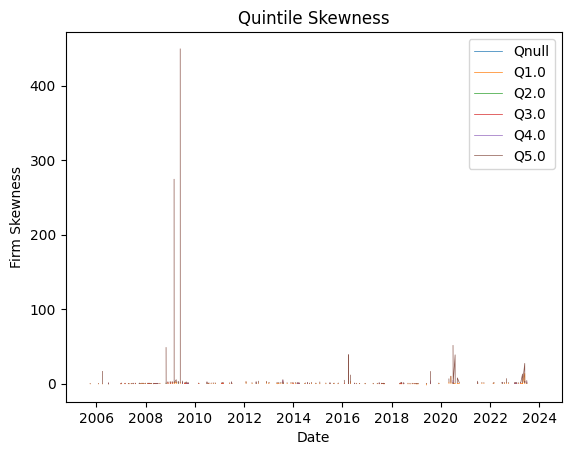

statistic,date,null,1.0,2.0,3.0,4.0,5.0
str,str,f64,f64,f64,f64,f64,f64
"""count""","""1058""",0.0,383.0,243.0,260.0,243.0,383.0
"""null_count""","""0""",1058.0,675.0,815.0,798.0,815.0,675.0
"""mean""","""2014-12-19 04:37:39.357000""",null,0.179028,0.192981,0.388064,0.455235,3.411127
"""std""",null,null,0.946532,0.311388,1.273582,0.542639,27.211255
"""min""","""2005-08-31 00:00:00""",null,-1.75972,-0.291005,-0.233636,-0.166967,-0.30144
"""25%""","""2010-07-30 00:00:00""",null,-0.114037,-0.024101,0.065927,0.144136,0.366635
"""50%""","""2015-06-10 00:00:00""",null,0.108254,0.213472,0.30478,0.413978,0.657779
"""75%""","""2019-04-10 00:00:00""",null,0.220425,0.291168,0.417915,0.578143,1.115987
"""max""","""2023-12-29 00:00:00""",null,13.898364,1.924035,19.843558,4.451883,449.298432


In [ ]:
# # shows expected skewness

# signal1= pl.from_pandas(signal)
# raw = (signal1.group_by(["date", "quintile"]).agg(pl.col("IS2").mean()).pivot(
#         values="IS2",
#         index="date",
#         columns="quintile", sort_columns=True
#     )
#     .sort("date")
#     .with_columns(pl.exclude('date')))

# dates= raw['date']

# for col in raw.columns:
#     if col != "date":
#         plt.plot(dates, raw[col], label=f"Q{col}", linewidth=0.5)

# plt.legend()
# plt.xlabel("Date")

# plt.ylabel("Firm Skewness")
# # plt.ylim(-1, 1)
# plt.title("Quintile Skewness")
# plt.show()
# raw.describe()

In [26]:
# calculates value weighted

signal["weight"] = (
    signal["mktcap_lag"] /
    signal.groupby(["date", "quintile"])["mktcap_lag"].transform("sum"))



vw_returns = (
    (signal["return"] * signal["weight"])
    .groupby([signal["date"], signal["quintile"]])
    .sum()
    .unstack()
)

vw_returns['spread'] = vw_returns[1]- vw_returns[5]
# vw_returns.describe()
dates= vw_returns.index
# print(dates)

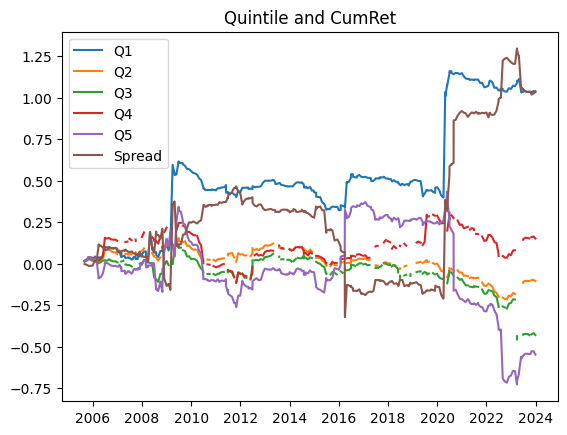

quintile,1.0,2.0,3.0,4.0,5.0,spread,cum1,cum2,cum3,cum4,cum5,Spread
count,368.000000,240.000000,256.000000,240.000000,368.000000,368.000000,368.000000,240.000000,256.000000,240.000000,368.000000,368.000000
mean,0.003994,-0.000349,-0.001443,0.000896,-0.000674,0.004668,0.504863,0.011762,-0.054240,0.105079,-0.011533,0.267116
std,0.058099,0.013181,0.020946,0.023434,0.040154,0.067271,0.330975,0.079548,0.109200,0.087664,0.252351,0.392346
min,-0.080000,-0.032892,-0.213542,-0.094869,-0.291432,-0.313645,0.008782,-0.213668,-0.456126,-0.115318,-0.727308,-0.322164
25%,-0.004569,-0.007368,-0.007530,-0.007782,-0.007627,-0.005397,0.348388,-0.014327,-0.071781,0.042733,-0.111478,-0.098089
50%,0.000000,-0.000322,-0.001109,-0.001012,0.000000,0.000000,0.472508,0.022772,-0.025594,0.107568,-0.034189,0.199163
75%,0.002702,0.005118,0.004654,0.005597,0.005821,0.004956,0.535338,0.068639,0.014721,0.159520,0.249033,0.370765
max,0.888604,0.061961,0.090909,0.178261,0.315534,0.810957,1.158335,0.154199,0.117149,0.306435,0.433853,1.295343


In [27]:
# dates = vw_returns['yyyymm']

for i in [1,2,3,4,5]:
    vw_returns[f'cum{i}'] = np.log(1 + vw_returns[i]).cumsum()
vw_returns[f'Spread'] = np.log(1 + vw_returns['spread']).cumsum()


for i in [1,2,3,4,5]:
    plt.plot(dates, vw_returns[f'cum{i}'], label=f'Q{i}')
    
plt.plot(dates, vw_returns['Spread'], label='Spread')
plt.title('Quintile and CumRet')
plt.legend()
plt.show()

vw_returns.describe()

In [ ]:
# does vol scaling


# 1. Calculate Rolling Volatility (using a 12-month window as an example)
# It is vital to sort by barrid and date for the rolling window to work
monthly_df = monthly_df.sort(["barrid", "date"])

monthly_df = monthly_df.with_columns(
    pl.col("return")
    .rolling_std(window_size=12)
    .over("barrid")
    .alias("vol")
)

# 2. Apply Signal Scaling
# We use a small epsilon or fill_null to avoid division by zero/nulls
signal_scaled = monthly_df.with_columns(
    (pl.col("IS2") / pl.col("vol")).alias("scaled_IS2")
).filter(pl.col("scaled_IS2").is_not_null() & pl.col("scaled_IS2").is_finite())

# 3. Create Quintiles based on the SCALED signal
signal_scaled = signal_scaled.with_columns(
    pl.col("scaled_IS2").rank(method="average").over("date").alias("rank")
)

signal_scaled = signal_scaled.with_columns(
    ((pl.col("rank") / pl.col("scaled_IS2").count().over("date") * 5).ceil().cast(pl.Int32))
    .alias("quintile")
)

# 4. Aggregate Equal-Weighted Returns per Quintile
# Even though the signal is scaled, we usually calculate EW returns 
# of the resulting buckets to see the effect of the scaling.
quintile_rets = (
    signal_scaled.group_by(["date", "quintile"])
    .agg(pl.col("return").mean().alias("quint_ret"))
    .sort(["date", "quintile"])
)

# 5. Cumulative Returns for plotting
ew_final = (
    quintile_rets.with_columns(
        pl.col("quint_ret").log1p().cum_sum().over("quintile").alias("cum_ret")
    )
    .pivot(values="cum_ret", index="date", on="quintile", sort_columns=True)
    .sort("date")
)

# 6. Calculate the Long/Short Spread
ew_final = ew_final.with_columns((pl.col('1') - pl.col('5')).alias('spread'))

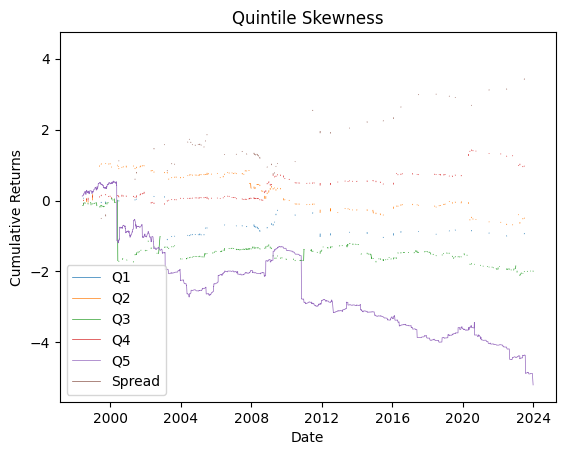

In [ ]:
ew_final


dates= ew_final['date']

for col in ew_final.columns:
    if col != "date" and col != 'spread':
        plt.plot(dates, ew_final[col], label=f"Q{col}", linewidth=0.5)
    if col == "spread":
        plt.plot(dates, ew_final[col], label=f"Spread", linewidth=0.5)

plt.legend()
plt.xlabel("Date")
# plt.ylim(-1,1)
plt.ylabel("Cumulative Returns")
plt.title("Quintile Skewness")
plt.show()